In [163]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import math
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [164]:
housing = fetch_california_housing()
print(housing.data.shape, housing.target.shape)

(20640, 8) (20640,)


In [165]:
print(housing.feature_names)

['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


In [166]:
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['Price'] = housing.target
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [167]:
df.isna().sum()

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
Price         0
dtype: int64

Text(0.5, 1.0, 'Correlation Heatmap')

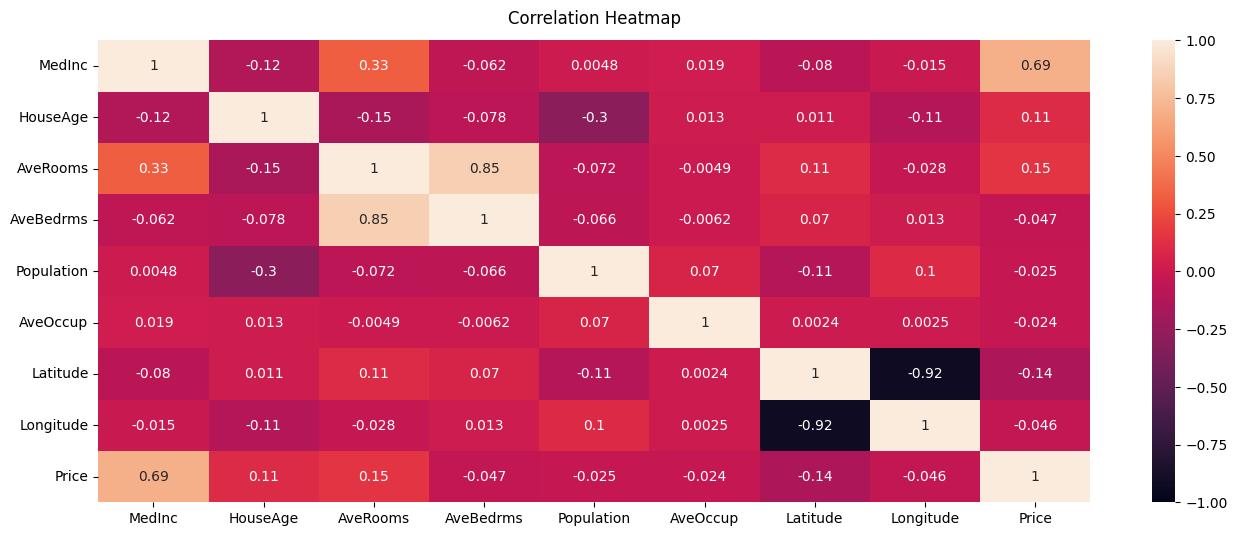

In [168]:
# https://medium.com/@szabo.bibor/how-to-create-a-seaborn-correlation-heatmap-in-python-834c0686b88e
plt.figure(figsize=(16, 6))
heatmap = sns.heatmap(df.corr(), vmin=-1, vmax=1, annot=True)
heatmap.set_title('Correlation Heatmap', fontdict={'fontsize':12}, pad=12)

Text(0.5, 1.0, 'Features Correlating with Price')

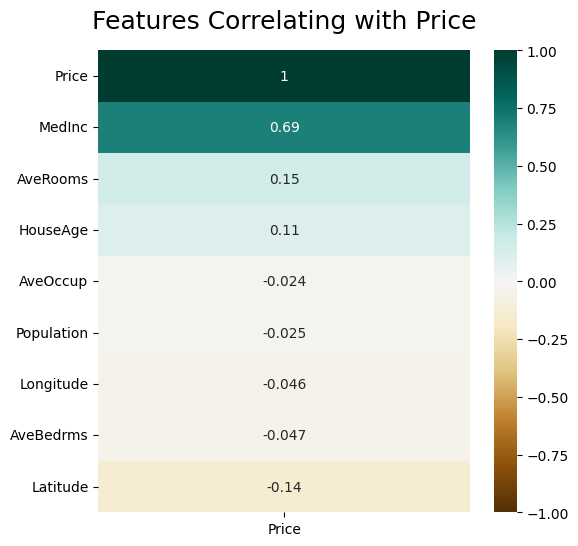

In [169]:
plt.figure(figsize=(6, 6))
heatmap = sns.heatmap(df.corr()[['Price']].sort_values(by='Price', ascending=False), vmin=-1, vmax=1, annot=True, cmap='BrBG')
heatmap.set_title('Features Correlating with Price', fontdict={'fontsize':18}, pad=16)

Text(0.5, 1.0, 'Features Correlating with MedInc')

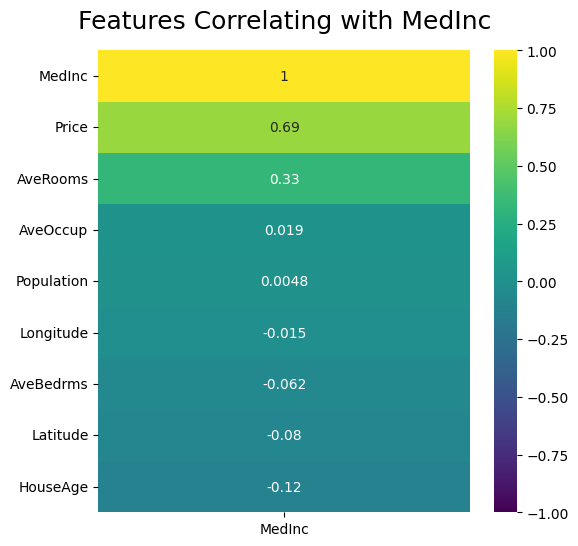

In [170]:
plt.figure(figsize=(6, 6))
heatmap = sns.heatmap(df.corr()[['MedInc']].sort_values(by='MedInc', ascending=False), vmin=-1, vmax=1, annot=True, cmap='viridis')
heatmap.set_title('Features Correlating with MedInc', fontdict={'fontsize':18}, pad=16)

In [171]:
selected_cols = ['MedInc','HouseAge']
X = df[selected_cols]
X

,MedInc,HouseAge
0,8.3252,41.0
1,8.3014,21.0
2,7.2574,52.0
3,5.6431,52.0
4,3.8462,52.0
...,...,...
20635,1.5603,25.0
20636,2.5568,18.0
20637,1.7000,17.0
20638,1.8672,18.0


In [172]:
y = df[['Price']]
y

,Price
0,4.526
1,3.585
2,3.521
3,3.413
4,3.422
...,...
20635,0.781
20636,0.771
20637,0.923
20638,0.847


In [173]:
X_train, X_test, y_train,  y_test = train_test_split(X,y, test_size=0.2)
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(16512, 2) (16512, 1) (4128, 2) (4128, 1)


In [174]:
X_train.head()

,MedInc,HouseAge
13525,3.2232,35.0
15625,3.6065,52.0
8392,2.6823,19.0
19376,5.5228,14.0
6845,2.3393,19.0


In [175]:
standard_scaler = StandardScaler()
X_train = standard_scaler.fit_transform(X_train)
# X_train = pd.DataFrame(X_train, columns=selected_cols)
X_train

array([[-0.33996718,  0.50021644],
       [-0.13854323,  1.84757958],
       [-0.62420986, -0.76789005],
       ...,
       [-0.2696028 , -1.16417333],
       [-0.73750755,  0.65872975],
       [-0.12882149,  0.65872975]], shape=(16512, 2))

In [176]:
X_test = standard_scaler.transform(X_test)
# X_test = pd.DataFrame(X_test, columns=selected_cols)
X_test

array([[-1.18581117, -1.16417333],
       [-0.23675908,  1.13426968],
       [-0.72410731, -0.60937674],
       ...,
       [ 0.83878074, -0.29235012],
       [-0.72000842,  0.26244647],
       [-0.72715521,  0.97575637]], shape=(4128, 2))

In [177]:
X_train = torch.tensor(X_train,dtype=torch.float32)
X_test = torch.tensor(X_test,dtype=torch.float32)
print('X_train tensor: ',X_train)
print('X_test tensor: ',X_test)


X_train tensor:  tensor([[-0.3400,  0.5002],
        [-0.1385,  1.8476],
        [-0.6242, -0.7679],
        ...,
        [-0.2696, -1.1642],
        [-0.7375,  0.6587],
        [-0.1288,  0.6587]])
X_test tensor:  tensor([[-1.1858, -1.1642],
        [-0.2368,  1.1343],
        [-0.7241, -0.6094],
        ...,
        [ 0.8388, -0.2924],
        [-0.7200,  0.2624],
        [-0.7272,  0.9758]])


### Mathematical Formulation of the Model (Perceptron)
**1. Forward Pass (Linear Combination):**
$$\hat{y} = w_1 x_1 + w_2 x_2 + b$$

**2. Loss Function (Mean Squared Error):**
$$J(W, b) = \frac{1}{N} \sum_{i=1}^{N} (\hat{y}^{(i)} - y^{(i)})^2$$

**3. Gradient Descent Update Rule:**
$$W \leftarrow W - \alpha \frac{\partial J}{\partial W}$$

In [178]:
# https://www.youtube.com/watch?v=2NzVvqCRQZQ
perceptron_linear = nn.Linear(in_features=2, out_features=1)
predictions = perceptron_linear(X_train)
print(X_train.shape, predictions.shape)
predictions

torch.Size([16512, 2]) torch.Size([16512, 1])


tensor([[-0.1392],
        [-0.5566],
        [ 0.2810],
        ...,
        [ 0.2845],
        [-0.0668],
        [-0.2423]], grad_fn=<AddmmBackward0>)

In [179]:
y_train = torch.tensor(np.array(y_train), dtype=torch.float32)

In [180]:
criterion = nn.MSELoss()
loss = criterion(predictions, y_train)
loss.item()

6.728328704833984

In [181]:
optimizer = optim.SGD(perceptron_linear.parameters(),lr=0.01)

In [182]:
epochs = 100
for epoch in range(epochs):
    y_pred = perceptron_linear(X_train)
    loss = criterion(y_pred, y_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    if epoch % 10 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')

Epoch [1/100], Loss: 6.7283
Epoch [11/100], Loss: 4.7412
Epoch [21/100], Loss: 3.4056
Epoch [31/100], Loss: 2.5075
Epoch [41/100], Loss: 1.9033
Epoch [51/100], Loss: 1.4966
Epoch [61/100], Loss: 1.2227
Epoch [71/100], Loss: 1.0381
Epoch [81/100], Loss: 0.9137
Epoch [91/100], Loss: 0.8297


In [183]:
print("Weights: ",perceptron_linear.weight)
print("Bias: ",perceptron_linear.bias)

Weights:  Parameter containing:
tensor([[0.6562, 0.1165]], requires_grad=True)
Bias:  Parameter containing:
tensor([1.7829], requires_grad=True)


In [186]:
w1 = perceptron_linear.weight[0][0].item()
w2 = perceptron_linear.weight[0][1].item()
b = perceptron_linear.bias[0].item()

X_numpy = X_test.numpy()
y_actual = y_test.to_numpy().flatten()

x1_range = np.linspace(X_numpy[:, 0].min(), X_numpy[:, 0].max(), 50)
x2_range = np.linspace(X_numpy[:, 1].min(), X_numpy[:, 1].max(), 50)
X1_mesh, X2_mesh = np.meshgrid(x1_range, x2_range)
Z_pred = w1 * X1_mesh + w2 * X2_mesh + b

y_pred_points = w1 * X_numpy[:, 0] + w2 * X_numpy[:, 1] + b
residuals = y_actual - y_pred_points


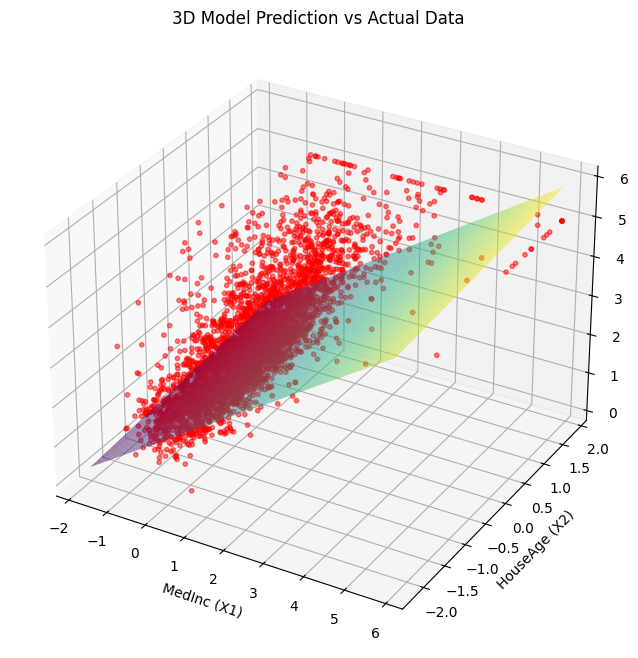

In [ ]:
fig1 = plt.figure(figsize=(10, 8))
ax1 = fig1.add_subplot(111, projection='3d')

ax1.plot_surface(X1_mesh, X2_mesh, Z_pred, alpha=0.5, cmap='viridis')

ax1.scatter(X_numpy[:, 0], X_numpy[:, 1], y_actual, color='red', s=10, alpha=0.5)

ax1.set_xlabel('MedInc (X1)')
ax1.set_ylabel('HouseAge (X2)')
ax1.set_zlabel('Price (Y)')
ax1.set_title('3D Model Prediction vs Actual Data')

plt.show()


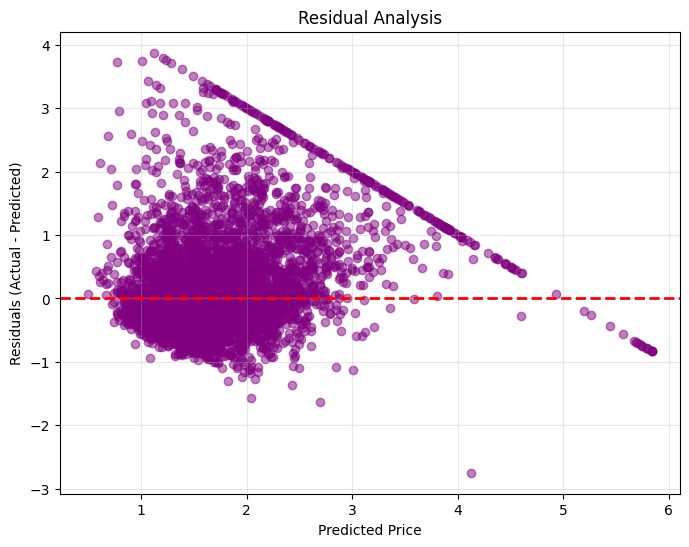

In [188]:
fig2 = plt.figure(figsize=(8, 6))

plt.scatter(y_pred_points, residuals, alpha=0.5, color='purple')

plt.axhline(y=0, color='red', linestyle='--', linewidth=2)

plt.xlabel('Predicted Price')
plt.ylabel('Residuals (Actual - Predicted)')
plt.title('Residual Analysis')
plt.grid(True, alpha=0.3)

plt.show()


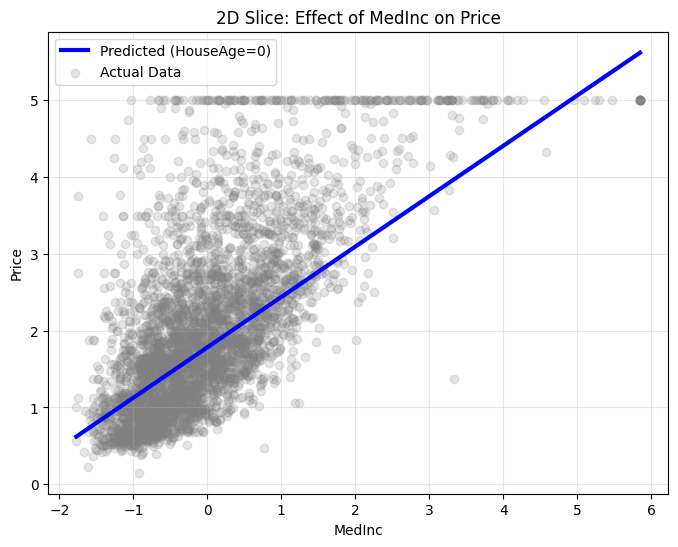

In [189]:
fig3 = plt.figure(figsize=(8, 6))

y_slice_pred = w1 * x1_range + (w2 * 0) + b 

plt.plot(x1_range, y_slice_pred, color='blue', linewidth=3, label='Predicted (HouseAge=0)')

plt.scatter(X_numpy[:, 0], y_actual, alpha=0.2, color='gray', label='Actual Data')

plt.xlabel('MedInc')
plt.ylabel('Price')
plt.title('2D Slice: Effect of MedInc on Price')
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()
